### Movie Review Sentiment Analysis

In this study we want to construct and compare different ML models and benchmark them on the same dataset.
The dataset consists of movie reviews with labels indicating positive or negative sentiment.

In [46]:

import numpy as np
import pandas as pd
import re
import pickle

from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
import spacy

from gensim.models import KeyedVectors

import tensorflow
from tensorflow.keras.layers import TextVectorization, Embedding, SimpleRNN, Dense, Input, Lambda, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt

tqdm.pandas()


### Load Dataset

In [25]:
df = pd.read_csv("movie.csv")
labels = df["label"]
reviews = df["text"]
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


### Data Preparation

In [26]:
nlp = spacy.load("en_core_web_sm")

try:
    with open('prepared_movie_reviews.pickle', 'rb') as file:
        reviews = pickle.load(file)
except Exception:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

    def remove_stopwords(text: str) -> str:
        text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
        return text

    reviews = reviews.progress_apply(remove_stopwords)

    nlp = spacy.load("en_core_web_sm")

    def lemmatize(text: str) -> str:
        text = nlp(text)
        s = ""
        for w in text:
            s += " " + w.lemma_
        return s

    reviews = reviews.progress_apply(lemmatize)

    with open('prepared_movie_reviews.pickle', 'wb') as file:
        pickle.dump(reviews, file)

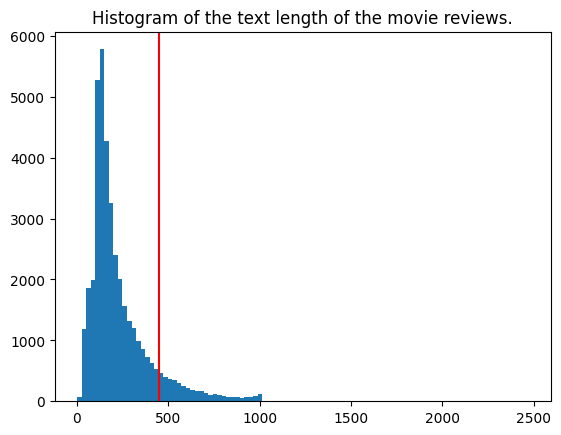

In [27]:
lengths = df["text"].apply(lambda txt: len(txt.split(" ")))

plt.hist(lengths, bins=100)
plt.title("Histogram of the text length of the movie reviews.")

max_token_cutoff = int(np.quantile(lengths, 0.9)) + 1

plt.axvline(max_token_cutoff, color="red")
plt.show()

In [28]:
tokenizer = TextVectorization(
    max_tokens=max_token_cutoff,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=max_token_cutoff,
    encoding='utf-8',
)

tokenizer.adapt(reviews.apply(str))


### Build Model

In [92]:
model = Sequential()

model.add(Input(shape=(1,), dtype=tensorflow.string))

model.add(tokenizer)

#model.add(Embedding(input_dim=num_vocabulary, output_dim=embedding_dim,
#                    weights=[embedding_matrix],
#                    input_length=max_token_cutoff,
#                    trainable = False), )

model.add(Embedding(
    input_dim=tokenizer.vocabulary_size(),
    output_dim=128,
    mask_zero=True
))

from tensorflow.keras.layers import LSTM

model.add(Bidirectional(LSTM(64, return_sequences=True)))

model.add(LSTM(32))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


In [93]:
dataset_size = labels.shape[0]
train_indices = np.random.choice(range(dataset_size), int(0.7 * dataset_size), replace=False)

X_train = reviews[train_indices].apply(str)
X_test = reviews[~np.isin(np.arange(dataset_size), train_indices)].apply(str).tolist()
y_train = labels[train_indices]
y_test = labels[~np.isin(np.arange(dataset_size), train_indices)]

In [94]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

vectorizer = CountVectorizer()
wordcounts = vectorizer.fit_transform(reviews)

X4_train, X4_test, y4_train, y4_test = train_test_split(wordcounts, labels, test_size=0.35, random_state=42)

clf = MultinomialNB()
clf.fit(X4_train, y4_train)
y4_predict = clf.predict(X4_test)
print(classification_report(y4_test, y4_predict))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      6925
           1       0.87      0.82      0.85      7075

    accuracy                           0.85     14000
   macro avg       0.85      0.85      0.85     14000
weighted avg       0.85      0.85      0.85     14000



In [95]:
model.fit(np.array(X_train, dtype=object), y_train, epochs=15, batch_size=120, validation_split=0.2, verbose=1)

Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.6090 - loss: 0.6460 - val_accuracy: 0.7480 - val_loss: 0.5156
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7782 - loss: 0.4774 - val_accuracy: 0.7652 - val_loss: 0.5135
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7737 - loss: 0.4926 - val_accuracy: 0.8125 - val_loss: 0.4354
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8043 - loss: 0.4375 - val_accuracy: 0.7873 - val_loss: 0.4575
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.7990 - loss: 0.4371 - val_accuracy: 0.7795 - val_loss: 0.4718
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.7999 - loss: 0.4481 - val_accuracy: 0.8223 - val_loss: 0.3992
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8266 - loss: 0.3908 - val_accuracy: 0.8368 - val_loss: 0.3792
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.8396 - loss: 0.3651 - val_ac

In [96]:
loss, accuracy = model.evaluate(np.array(X_test, dtype=object), y_test, verbose=1)
print(f"Test loss: {loss}, Test accuracy: {accuracy}")
model.save("movie_review_model.h5")

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8433 - loss: 0.3494


Test loss: 0.35774797201156616, Test accuracy: 0.8395000100135803


In [97]:
y_predict = model.predict(np.array(X_test, dtype=object))
print(classification_report(y_test, (y_predict > 0.5).astype(int)))

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      6107
           1       0.83      0.85      0.84      5893

    accuracy                           0.84     12000
   macro avg       0.84      0.84      0.84     12000
weighted avg       0.84      0.84      0.84     12000

